# Primer intento:

La intuicion inicial es probar divisores impares hasta la raiz cuadrada del numero y registrar el ultimo factor encontrado.

In [11]:
def primer_intento():
    n = 600851475143
    raiz = int(n ** 0.5 // 1)
    p = 0
    for i in range(3, raiz, 2):
        while n % i == 0:
            n /= i
            p = i
    return p


primer_intento()

6857

# Optimizacion:

chatgpt recomienda ir reduciendo el numero cada vez que aparece un factor, de modo que el mayor factor primo restante surja al final sin recorrer todo el rango inicial:

In [12]:
def optimizacion():
    n = 600851475143
    while n % 2 == 0: # por si fuera par
        n //= 2
    i = 3
    while i * i <= n:
        while n % i == 0:
            n //= i
        i += 2
    return n

optimizacion()

6857

# Comparacion:

Esta celda compara ambos metodos en tiempo y memoria.


--- Primer intento ---
Resultado: 6857
Consistente: True
Tiempo promedio: 0.029185 s
Tiempo minimo: 0.027655 s
Memoria promedio: 0.23 KB
Memoria maxima: 2.28 KB

--- Optimizacion ---
Resultado: 6857
Consistente: True
Tiempo promedio: 0.000069 s
Tiempo minimo: 0.000067 s
Memoria promedio: 0.07 KB
Memoria maxima: 0.09 KB


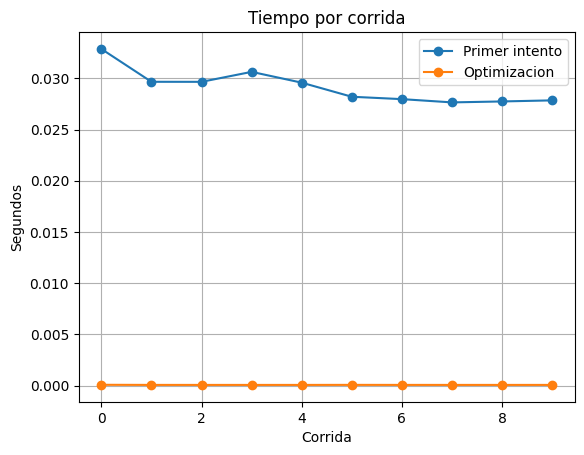

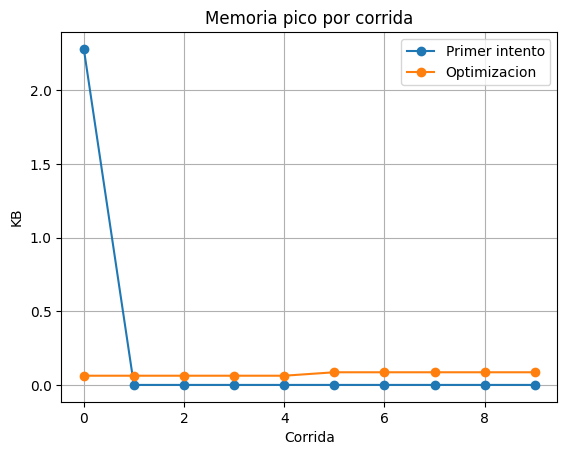

In [13]:
import time
import tracemalloc
import matplotlib.pyplot as plt


def medir(funcion, corridas=10):
    tiempos = []
    memorias = []
    resultados = []

    for _ in range(corridas):
        tracemalloc.start()

        tiempo_inicial = time.process_time()
        resultado = funcion()
        tiempo_final = time.process_time()

        _, memoria_pico = tracemalloc.get_traced_memory()
        tracemalloc.stop()

        tiempos.append(tiempo_final - tiempo_inicial)
        memorias.append(memoria_pico / 1024)
        resultados.append(resultado)

    return {
        "resultado": resultados[0] if len(set(resultados)) == 1 else None,
        "consistente": len(set(resultados)) == 1,
        "tiempos": tiempos,
        "memorias": memorias,
    }


metodos = {
    "Primer intento": primer_intento,
    "Optimizacion": optimizacion,
}

comparaciones = {
    nombre: medir(funcion, corridas=10)
    for nombre, funcion in metodos.items()
}

for nombre, datos in comparaciones.items():
    print(f"\n--- {nombre} ---")
    print("Resultado:", datos["resultado"])
    print("Consistente:", datos["consistente"])
    print(f"Tiempo promedio: {sum(datos['tiempos']) / len(datos['tiempos']):.6f} s")
    print(f"Tiempo minimo: {min(datos['tiempos']):.6f} s")
    print(f"Memoria promedio: {sum(datos['memorias']) / len(datos['memorias']):.2f} KB")
    print(f"Memoria maxima: {max(datos['memorias']):.2f} KB")


plt.figure()
for nombre, datos in comparaciones.items():
    plt.plot(datos["tiempos"], marker="o", label=nombre)
plt.title("Tiempo por corrida")
plt.xlabel("Corrida")
plt.ylabel("Segundos")
plt.legend()
plt.grid()

plt.figure()
for nombre, datos in comparaciones.items():
    plt.plot(datos["memorias"], marker="o", label=nombre)
plt.title("Memoria pico por corrida")
plt.xlabel("Corrida")
plt.ylabel("KB")
plt.legend()
plt.grid()

plt.show()